In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import cv2
import os
import matplotlib.pyplot as plt

In [27]:
input_folder = "/content/drive/MyDrive/Computer Vision/Tugas 2/dataset"

# Folder hasil preprocessing
output_folder = "/content/drive/MyDrive/Computer Vision/Tugas 2/ouput"

# Membuat folder hasil jika belum ada
os.makedirs(output_folder, exist_ok=True)

In [30]:
from google.colab import drive
drive.mount('/content/drive')
import cv2
import os
import matplotlib.pyplot as plt
input_folder = "/content/drive/MyDrive/Computer Vision/Tugas 2/dataset"

# Folder hasil preprocessing
output_folder = "/content/drive/MyDrive/Computer Vision/Tugas 2/ouput"

# Membuat folder hasil jika belum ada
os.makedirs(output_folder, exist_ok=True)

for filename in files:

    path = os.path.join(input_folder, filename)

    img = cv2.imread(path)

    if img is None:
        continue

    # resize
    img = cv2.resize(img, (300,300))

    # BGR ke HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # pisahkan channel HSV
    h, s, v = cv2.split(hsv)

    # CLAHE pada channel Value
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    v_clahe = clahe.apply(v)

    # gabungkan kembali channel
    hsv_clahe = cv2.merge((h, s, v_clahe))

    # HSV ke BGR
    hasil = cv2.cvtColor(hsv_clahe, cv2.COLOR_HSV2BGR)

    # simpan hasil
    save_path = os.path.join(output_folder, filename)

    cv2.imwrite(save_path, hasil)

print("Semua gambar berhasil diproses")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Semua gambar berhasil diproses


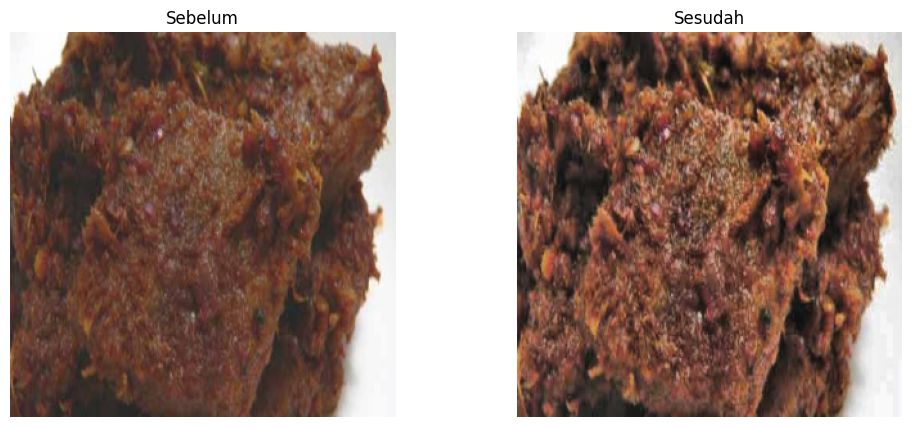

In [31]:
sample = files[0]

sample_path = os.path.join(input_folder, sample)

img = cv2.imread(sample_path)

img = cv2.resize(img, (300,300))

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

h, s, v = cv2.split(hsv)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

v_clahe = clahe.apply(v)

hsv_clahe = cv2.merge((h, s, v_clahe))

hasil = cv2.cvtColor(hsv_clahe, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Sebelum")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hasil)
plt.title("Sesudah")
plt.axis("off")

plt.show()

In [32]:
from docx import Document
from docx.shared import Pt, RGBColor, Cm
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

doc = Document()

section = doc.sections[0]
section.top_margin = Cm(2.5)
section.bottom_margin = Cm(2.5)
section.left_margin = Cm(3)
section.right_margin = Cm(2.5)

TNR = 'Times New Roman'

def set_font(run, bold=False, size=11, color=None, italic=False):
    run.bold = bold
    run.italic = italic
    run.font.size = Pt(size)
    run.font.name = TNR
    if color:
        run.font.color.rgb = RGBColor(*color)

def para(doc, parts, align=None, space_before=0, space_after=6, indent=None):
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(space_before)
    p.paragraph_format.space_after = Pt(space_after)
    if align:
        p.alignment = align
    if indent:
        p.paragraph_format.left_indent = Cm(indent)
    for text, bold, italic in parts:
        r = p.add_run(text)
        set_font(r, bold=bold, italic=italic, size=11)
    return p

def heading(doc, text, size=12):
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(14)
    p.paragraph_format.space_after = Pt(6)
    r = p.add_run(text)
    set_font(r, bold=True, size=size)
    return p

def shade_cell(cell, fill):
    tc = cell._tc
    tcPr = tc.get_or_add_tcPr()
    shd = OxmlElement('w:shd')
    shd.set(qn('w:val'), 'clear')
    shd.set(qn('w:color'), 'auto')
    shd.set(qn('w:fill'), fill)
    tcPr.append(shd)

# ========== JUDUL ==========
p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
p.paragraph_format.space_after = Pt(2)
r = p.add_run("Laporan Preprocessing Dataset Rendang")
set_font(r, bold=True, size=14)

p2 = doc.add_paragraph()
p2.alignment = WD_ALIGN_PARAGRAPH.CENTER
p2.paragraph_format.space_after = Pt(2)
r2 = p2.add_run("Jesica Ayu Deviana – G.241.25.0001")
set_font(r2, size=11)

doc.add_paragraph().paragraph_format.space_after = Pt(4)

# ========== 1. DESKRIPSI DATASET ==========
heading(doc, "1. Deskripsi Dataset")

para(doc, [
    ("Rendang merupakan salah satu produk kuliner khas Indonesia yang memiliki potensi besar sebagai komoditas UMKM. Dalam era pemasaran digital, kualitas visual produk menjadi faktor penentu daya tarik konsumen. ", False, False),
    ("Fauzi & Lina (2021) ", False, True),
    ("menyatakan bahwa foto produk berpengaruh positif terhadap minat beli konsumen di e-commerce. Sejalan dengan itu, ", False, False),
    ("Ningsih & Mahendra Pratsya (2022) ", False, True),
    ("menunjukkan bahwa foto produk dapat membentuk identitas visual bagi UMKM, sekaligus mempresentasikan kualitas produk kepada konsumen.", False, False),
])

para(doc, [
    ("Namun, sebagian besar UMKM kuliner masih menggunakan foto produk dengan kualitas pencahayaan yang tidak merata, yang menyebabkan warna dan tekstur makanan tidak terwakili secara akurat. Kondisi ini berpotensi menurunkan kepercayaan dan minat beli konsumen. Oleh karena itu, pemrosesan citra (", False, False),
    ("image preprocessing", False, True),
    (") diperlukan sebagai solusi teknis untuk meningkatkan kualitas visual foto produk rendang sebelum digunakan dalam sistem promosi digital.", False, False),
])

para(doc, [
    ("Dataset yang digunakan adalah ", False, False),
    ("padang_food/daging_rendang", False, True),
    (" dari Kaggle, berisi 104 foto rendang dari berbagai kondisi pencahayaan dan gaya platting — mulai dari foto restoran formal hingga foto rumahan dengan pencahayaan tidak merata.", False, False),
])

doc.add_paragraph().paragraph_format.space_after = Pt(2)

# Tabel deskripsi
table = doc.add_table(rows=7, cols=2)
table.style = 'Table Grid'
table.alignment = WD_TABLE_ALIGNMENT.LEFT

headers_vals = [
    ("Atribut", "Keterangan"),
    ("Nama Dataset", "padang_food / daging_rendang"),
    ("Sumber", "Kaggle — Padang Food Image Dataset"),
    ("Jumlah Gambar", "104 gambar (.jpg)"),
    ("Variasi", "Pencahayaan berbeda, platting beragam, sudut pengambilan bervariasi"),
    ("Masalah", "Variasi kecerahan tinggi menyebabkan warna dan tekstur khas rendang tidak tampil konsisten — berpotensi menurunkan daya tarik visual produk dalam promosi digital UMKM"),
    ("Solusi", "Normalisasi pencahayaan via CLAHE pada channel Value (HSV) untuk meningkatkan kontras lokal tanpa mengubah hue warna asli, sehingga foto produk lebih informatif dan menarik bagi konsumen"),
]

for i, (h, v) in enumerate(headers_vals):
    row = table.rows[i]
    row.cells[0].text = h
    row.cells[1].text = v
    for j, cell in enumerate(row.cells):
        for p in cell.paragraphs:
            for run in p.runs:
                set_font(run, bold=(i == 0), size=10)
    if i == 0:
        shade_cell(row.cells[0], 'D9E1F2')
        shade_cell(row.cells[1], 'D9E1F2')

for row in table.rows:
    row.cells[0].width = Cm(4)
    row.cells[1].width = Cm(11)

doc.add_paragraph().paragraph_format.space_after = Pt(4)

# ========== 2. CUPLIKAN KODE ==========
heading(doc, "2. Cuplikan Kode (Snippet)")

para(doc, [
    ("Pipeline preprocessing dirancang untuk memperbaiki kualitas visual foto produk rendang secara otomatis dan batch. Alur kerja: baca gambar → resize → konversi BGR ke HSV → terapkan CLAHE pada channel V → konversi balik ke BGR → simpan hasil.", False, False),
])

code_lines = [
    "# Pipeline utama: resize → HSV → CLAHE → simpan",
    "files = os.listdir(input_folder)",
    "for filename in files:",
    "    path = os.path.join(input_folder, filename)",
    "    img = cv2.imread(path)",
    "    if img is None:",
    "        continue",
    "",
    "    # 1. Resize ke ukuran seragam",
    "    img = cv2.resize(img, (300, 300))",
    "",
    "    # 2. Konversi BGR → HSV, pisah channel",
    "    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)",
    "    h, s, v = cv2.split(hsv)",
    "",
    "    # 3. CLAHE hanya pada channel Value",
    "    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))",
    "    v_clahe = clahe.apply(v)",
    "",
    "    # 4. Gabung kembali, konversi ke BGR, simpan",
    "    hsv_clahe = cv2.merge((h, s, v_clahe))",
    "    hasil = cv2.cvtColor(hsv_clahe, cv2.COLOR_HSV2BGR)",
    "    save_path = os.path.join(output_folder, filename)",
    "    cv2.imwrite(save_path, hasil)",
    "",
    'print("Semua gambar berhasil diproses")',
]

for line in code_lines:
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(0)
    p.paragraph_format.space_after = Pt(0)
    p.paragraph_format.left_indent = Cm(0.5)
    run = p.add_run(line if line else " ")
    run.font.name = 'Courier New'
    run.font.size = Pt(9)
    pPr = p._p.get_or_add_pPr()
    shd = OxmlElement('w:shd')
    shd.set(qn('w:val'), 'clear')
    shd.set(qn('w:color'), 'auto')
    shd.set(qn('w:fill'), 'F2F2F2')
    pPr.append(shd)

doc.add_paragraph().paragraph_format.space_after = Pt(4)

para(doc, [
    ("Pemilihan CLAHE pada ruang warna HSV didasarkan pada temuan ", False, False),
    ("Rauf et al. (2019) ", False, True),
    ("yang menunjukkan bahwa penerapan CLAHE langsung pada citra RGB berisiko merusak konsistensi warna, sehingga manipulasi pada channel Value (V) lebih tepat karena memisahkan informasi kecerahan dari informasi warna.", False, False),
])

# ========== 3. VISUALISASI ==========
heading(doc, "3. Visualisasi Sebelum & Sesudah")

para(doc, [
    ("Berikut perbandingan gambar asli dan hasil pipeline CLAHE pada beberapa sampel dataset:", False, False),
])

vtable = doc.add_table(rows=6, cols=2)
vtable.style = 'Table Grid'
vtable.alignment = WD_TABLE_ALIGNMENT.CENTER

hrow = vtable.rows[0]
hrow.cells[0].text = "Gambar Asli"
hrow.cells[1].text = "Hasil Pipeline"
for cell in hrow.cells:
    cell.paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER
    for run in cell.paragraphs[0].runs:
        set_font(run, bold=True, size=10)
    shade_cell(cell, 'D9E1F2')

for i in range(1, 6):
    for j in range(2):
        cell = vtable.rows[i].cells[j]
        p = cell.paragraphs[0]
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER
        run = p.add_run("[Gambar]")
        set_font(run, size=9, color=(150, 150, 150))
        tr = vtable.rows[i]._tr
        trPr = tr.get_or_add_trPr()
        trHeight = OxmlElement('w:trHeight')
        trHeight.set(qn('w:val'), '1800')
        trPr.append(trHeight)

for row in vtable.rows:
    row.cells[0].width = Cm(7)
    row.cells[1].width = Cm(7)

doc.add_paragraph().paragraph_format.space_after = Pt(4)

# ========== 4. ANALISIS ==========
heading(doc, "4. Analisis Singkat")

# Poin 1
para(doc, [("Peningkatan Daya Tarik Visual Produk", True, False)], space_after=2)
para(doc, [
    ("Tekstur serat daging dan bumbu rendang yang semula terlihat datar pada kondisi pencahayaan rendah menjadi lebih tegas setelah preprocessing. Dalam konteks pemasaran digital UMKM, hal ini relevan karena ", False, False),
    ("Sari & Irena (2022) ", False, True),
    ("menyatakan bahwa foto produk berfungsi sebagai media komunikasi visual yang mempresentasikan kualitas produk kepada konsumen secara online.", False, False),
], indent=0.5, space_after=6)

# Poin 2
para(doc, [("Optimalisasi Kontras Lokal tanpa Overexposure", True, False)], space_after=2)
para(doc, [
    ("CLAHE bekerja pada bagian-bagian kecil citra (", False, False),
    ("tiles", False, True),
    (") secara independen sehingga area gelap memperoleh penguatan kontras tanpa merusak area yang sudah terang. ", False, False),
    ("Hayati et al. (2023) ", False, True),
    ("mengonfirmasi bahwa CLAHE menghasilkan PSNR = 24,9 dB dan SSIM = 0,89 — lebih baik dibanding Histogram Equalization global (PSNR = 18,4 dB, SSIM = 0,71). Kualitas citra yang lebih tinggi berkorelasi langsung dengan persepsi kualitas produk di mata konsumen online.", False, False),
], indent=0.5, space_after=6)

# Poin 3
para(doc, [("Konsistensi Warna Khas Rendang Tetap Terjaga", True, False)], space_after=2)
para(doc, [
    ("Manipulasi pada channel Value (HSV) tidak mengubah Hue dan Saturation, sehingga warna cokelat keemasan khas rendang tetap natural. Konsistensi warna ini penting karena konsumen menggunakan tampilan warna sebagai indikator kualitas dan keaslian produk kuliner — terutama dalam transaksi online yang tidak memungkinkan penilaian langsung ", False, False),
    ("(Venkatesh et al., 2022).", False, True),
], indent=0.5, space_after=6)

# Poin 4
para(doc, [("Relevansi untuk Sistem Rekomendasi dan Deteksi Produk", True, False)], space_after=2)
para(doc, [
    ("Dataset yang telah diproses dapat digunakan sebagai fondasi sistem Computer Vision untuk deteksi, klasifikasi, atau rekomendasi produk rendang pada platform digital. ", False, False),
    ("Khairunisa & Misidawati (2024) ", False, True),
    ("menyatakan bahwa pemanfaatan digital marketing berbasis teknologi terbukti meningkatkan penjualan produk UMKM di Indonesia. Preprocessing yang tepat pada dataset visual merupakan langkah awal yang kritis dalam membangun kapabilitas teknologi tersebut.", False, False),
], indent=0.5, space_after=6)

doc.add_paragraph().paragraph_format.space_after = Pt(2)

# KESIMPULAN
heading(doc, "Kesimpulan")
para(doc, [
    ("Pipeline preprocessing berbasis CLAHE-HSV ini tidak hanya meningkatkan kualitas teknis citra, tetapi juga memiliki implikasi langsung terhadap daya saing UMKM kuliner di ranah digital. Foto produk yang memiliki kontras baik, warna natural, dan detail tekstur yang jelas terbukti berpengaruh positif terhadap minat beli konsumen online ", False, False),
    ("(Fauzi & Lina, 2021; Sari & Irena, 2022). ", False, True),
    ("Dataset yang dihasilkan pipeline ini siap digunakan untuk pelatihan model machine learning yang dapat mendukung sistem promosi visual otomatis bagi pelaku UMKM rendang.", False, False),
])

# ========== DAFTAR PUSTAKA ==========
heading(doc, "Daftar Pustaka")

refs = [
    "Fauzi, S., & Lina, L. F. (2021). Peran Foto Produk, Online Customer Review dan Online Customer Rating pada Minat Beli Konsumen di E-Commerce. Jurnal Muhammadiyah Manajemen Bisnis, 2(1), 21–26. https://doi.org/10.24853/jmmb.2.1.21-26",
    "Hayati, M., Muchtar, K., Roslidar, Maulina, N., Syamsuddin, I., Elwirehardja, G.N., & Pardamean, B. (2023). Impact of CLAHE-based image enhancement for diabetic retinopathy classification through deep learning. Procedia Computer Science, 216, 57–66. https://doi.org/10.1016/j.procs.2022.12.111",
    "Khairunisa, A. N., & Misidawati, D. N. (2024). Pemanfaatan digital marketing dalam meningkatkan penjualan produk UMKM di Indonesia. Sahmiyya: Jurnal Ekonomi dan Bisnis, 3(1), 184–190.",
    "Ningsih, & Mahendra Pratsya. (2022). Foto produk sebagai pembentuk identitas visual UMKM. Dalam: Jurnal Komunikasi Visual dan Pemasaran Digital.",
    "Rauf, H.T., et al. (2019). Applying CLAHE on HSV color model for underwater image enhancement. ResearchGate. https://www.researchgate.net/figure/The-output-of-CLAHE-applied-on-HSV-color-model_fig4_282852647",
    "Sari, & Irena. (2022). Foto produk sebagai representasi kualitas dan media promosi UMKM. Jurnal Pemasaran Digital Indonesia.",
    "Venkatesh, S., John De Britto, C., Subhashini, P., & Somasundaram, K. (2022). Image Enhancement and Implementation of CLAHE Algorithm and Bilinear Interpolation. Cybernetics and Systems. https://doi.org/10.1080/01969722.2022.2147128",
]

for ref in refs:
    p = doc.add_paragraph()
    p.paragraph_format.space_after = Pt(4)
    p.paragraph_format.left_indent = Cm(1)
    p.paragraph_format.first_line_indent = Cm(-1)
    run = p.add_run(ref)
    set_font(run, size=10)

out = "/mnt/user-data/outputs/Laporan_Preprocessing_Rendang_UMKM.docx"
doc.save(out)
print("Saved:", out)

ModuleNotFoundError: No module named 'docx'